# Import Data

In [198]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt
import seaborn as sns

## Functions

In [193]:
def get_num_cols(X, do_print=False):
    if do_print:
        print("\nNumerical Features:")
    cols = X.select_dtypes(include=[np.number])
    for col in cols.columns.tolist():
        col_type = X[col].dtypes
        unique_count = X[col].nunique()
        if do_print:
            print(f"{col}[{col_type}]: {unique_count}")

    return cols

def get_cat_cols(X, do_print=False):
    if do_print:
        print("\nCategorical Features:")
    cols = X.select_dtypes(exclude=[np.number])
    for col in cols.columns.tolist():
        col_type = X[col].dtypes
        unique_count = X[col].nunique()
        if do_print:
            print(f"{col}[{col_type}]: {unique_count}")

    return cols

def get_corr(X, c1, c2):
    print(X[c1].corr(X[c2]))

def get_low_variance_cols(X, cols):
    for col in cols:
        if X[col].nunique() < 20:
            print(col)
    
    if len(cols) < 2:
        print(X[col].unique())

def print_variances(num_cols):
    print("High Variance:")
    for col in num_cols.columns.tolist():
            unique_count = num_cols[col].nunique()
            if unique_count > 99:
                print(f"{col}: {unique_count}")

    print("\nMedium Variance:")
    for col in num_cols.columns.tolist():
            unique_count = num_cols[col].nunique()
            if unique_count > 15 and unique_count < 100:
                print(f"{col}: {unique_count}")

    print("\nLow Variance:")
    for col in num_cols.columns.tolist():
            unique_count = num_cols[col].nunique()
            if unique_count < 15:
                print(f"{col}: {unique_count}")

def model_performance(model, predictors, target):
    pred = model.predict(predictors)
    print(predictors, target, pred)
    r2 = r2_score(target, pred)
    rmse = np.sqrt(mean_squared_error(target, pred))
    mae = mean_absolute_error(target, pred)
    mape = np.mean(np.abs(target - pred) / target) * 100

    return pd.DataFrame({
        "R-squared": r2,
        "RMSE": rmse,
        "MAE": mae,
        "MAPE": mape
    }, index=[0])

def linreg(X, Y):
    model = LinearRegression()
    model.fit(X, Y)
    print(model_performance(model, X, Y))

def linreg_imputer(X, c1, c2):
    x_tmp_train = {c1: []}
    y_tmp_train = {c2: []}
    x_tmp_target = {c1: []}
    for _, row in x_df_train.iterrows():
        if not pd.isna(row[c2]):
            x_tmp_train[c1].append(row[c1])
            y_tmp_train[c2].append(row[c2])
        else:
            x_tmp_target[c1].append(row[c1])

    linreg(pd.DataFrame(x_tmp_train), pd.DataFrame(y_tmp_train))

In [195]:
df_train = pd.read_csv('./kaggle/house_prices/train.csv')
id_df_train = df_train['Id'].copy()
x_df_train = df_train.drop(['Id'], axis=1)

df_test = pd.read_csv('./kaggle/house_prices/test.csv')
id_df_test = df_test['Id'].copy()
x_df_test = df_test.drop(['Id'], axis=1)

In [196]:
num_cols = get_num_cols(x_df_train)

areas = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea',
    'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea'
]
ratings = ['OverallQual', 'OverallCond']
classes = ['MSSubClass']
dates = ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold']
values = ['MiscVal']
rooms = [
    'BsmtFullBath',
    'BsmtHalfBath',
    'FullBath',
    'HalfBath',
    'BedroomAbvGr',
    'KitchenAbvGr',
    'TotRmsAbvGrd',
    'Fireplaces',
    'GarageCars'
]

x_df_train['AG_TotalBaths'] = x_df_train['BsmtFullBath'] + x_df_train['BsmtHalfBath'] + x_df_train['FullBath'] + x_df_train['HalfBath']
x_df_train = x_df_train.drop(['BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath'], axis=1)

# Based on correlation analysis
x_df_train['AG_TotalMoSold'] = x_df_train['MoSold'] + (2011 - x_df_train['YrSold']) * 12
x_df_train = x_df_train.drop(['MoSold', 'YrSold'], axis=1)

num_cols = get_num_cols(x_df_train)
print_variances(num_cols)

High Variance:
LotFrontage: 110
LotArea: 1073
YearBuilt: 112
MasVnrArea: 327
BsmtFinSF1: 637
BsmtFinSF2: 144
BsmtUnfSF: 780
TotalBsmtSF: 721
1stFlrSF: 753
2ndFlrSF: 417
GrLivArea: 861
GarageArea: 441
WoodDeckSF: 274
OpenPorchSF: 202
EnclosedPorch: 120
SalePrice: 663

Medium Variance:
YearRemodAdd: 61
LowQualFinSF: 24
GarageYrBlt: 97
3SsnPorch: 20
ScreenPorch: 76
MiscVal: 21
AG_TotalMoSold: 55

Low Variance:
OverallQual: 10
OverallCond: 9
BedroomAbvGr: 8
KitchenAbvGr: 4
TotRmsAbvGrd: 12
Fireplaces: 4
GarageCars: 5
PoolArea: 8
AG_TotalBaths: 6


[38 53 45 62 48 34 56 35 40 37 67 41 55 15 70 42 29 71 54 17 31 72 43 16
 69 30 13 60 65 14 32 49 50 68 51 58 26 19 18 36 63 46 64 27 59 28 44 33
 52 39 25 66 61 47 57]


<Axes: xlabel='TotalMoSold', ylabel='Count'>

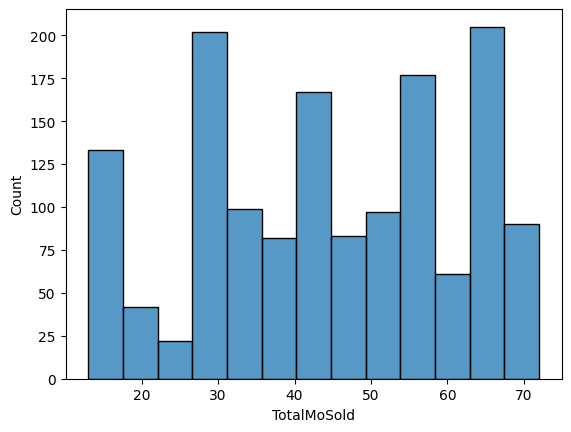

In [185]:
c = 'TotalMoSold'
print(x_df_train[c].unique())
sns.histplot(x_df_train[c])

In [197]:
correlations = x_df_train[num_cols.columns].corr()['SalePrice']
print(correlations.sort_values())

aggr_correlations = x_df_train[['TotalMoSold', 'SalePrice']].corr()['SalePrice']
print(aggr_correlations.sort_values())

KitchenAbvGr     -0.135907
EnclosedPorch    -0.128578
MSSubClass       -0.084284
OverallCond      -0.077856
LowQualFinSF     -0.025606
MiscVal          -0.021190
BsmtFinSF2       -0.011378
AG_TotalMoSold    0.035440
3SsnPorch         0.044584
PoolArea          0.092404
ScreenPorch       0.111447
BedroomAbvGr      0.168213
BsmtUnfSF         0.214479
LotArea           0.263843
OpenPorchSF       0.315856
2ndFlrSF          0.319334
WoodDeckSF        0.324413
LotFrontage       0.351799
BsmtFinSF1        0.386420
Fireplaces        0.466929
MasVnrArea        0.477493
GarageYrBlt       0.486362
YearRemodAdd      0.507101
YearBuilt         0.522897
TotRmsAbvGrd      0.533723
1stFlrSF          0.605852
AG_TotalBaths     0.613005
TotalBsmtSF       0.613581
GarageArea        0.623431
GarageCars        0.640409
GrLivArea         0.708624
OverallQual       0.790982
SalePrice         1.000000
Name: SalePrice, dtype: float64


KeyError: "['TotalMoSold'] not in index"

# Plots

In [ ]:
# Compute correlation matrix
corr_matrix = df_train[num_cols.columns].corr()

# Plot heatmap
plt.figure(figsize=(20, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap (Numeric Features)')
plt.show()


KitchenAbvGr    -0.135907
EnclosedPorch   -0.128578
MSSubClass      -0.084284
OverallCond     -0.077856
YrSold          -0.028923
LowQualFinSF    -0.025606
MiscVal         -0.021190
BsmtFinSF2      -0.011378
3SsnPorch        0.044584
MoSold           0.046432
PoolArea         0.092404
ScreenPorch      0.111447
BedroomAbvGr     0.168213
BsmtUnfSF        0.214479
LotArea          0.263843
OpenPorchSF      0.315856
2ndFlrSF         0.319334
WoodDeckSF       0.324413
LotFrontage      0.351799
BsmtFinSF1       0.386420
Fireplaces       0.466929
MasVnrArea       0.477493
GarageYrBlt      0.486362
YearRemodAdd     0.507101
YearBuilt        0.522897
TotRmsAbvGrd     0.533723
1stFlrSF         0.605852
TotalBaths       0.613005
TotalBsmtSF      0.613581
GarageArea       0.623431
GarageCars       0.640409
GrLivArea        0.708624
OverallQual      0.790982
SalePrice        1.000000
Name: SalePrice, dtype: float64


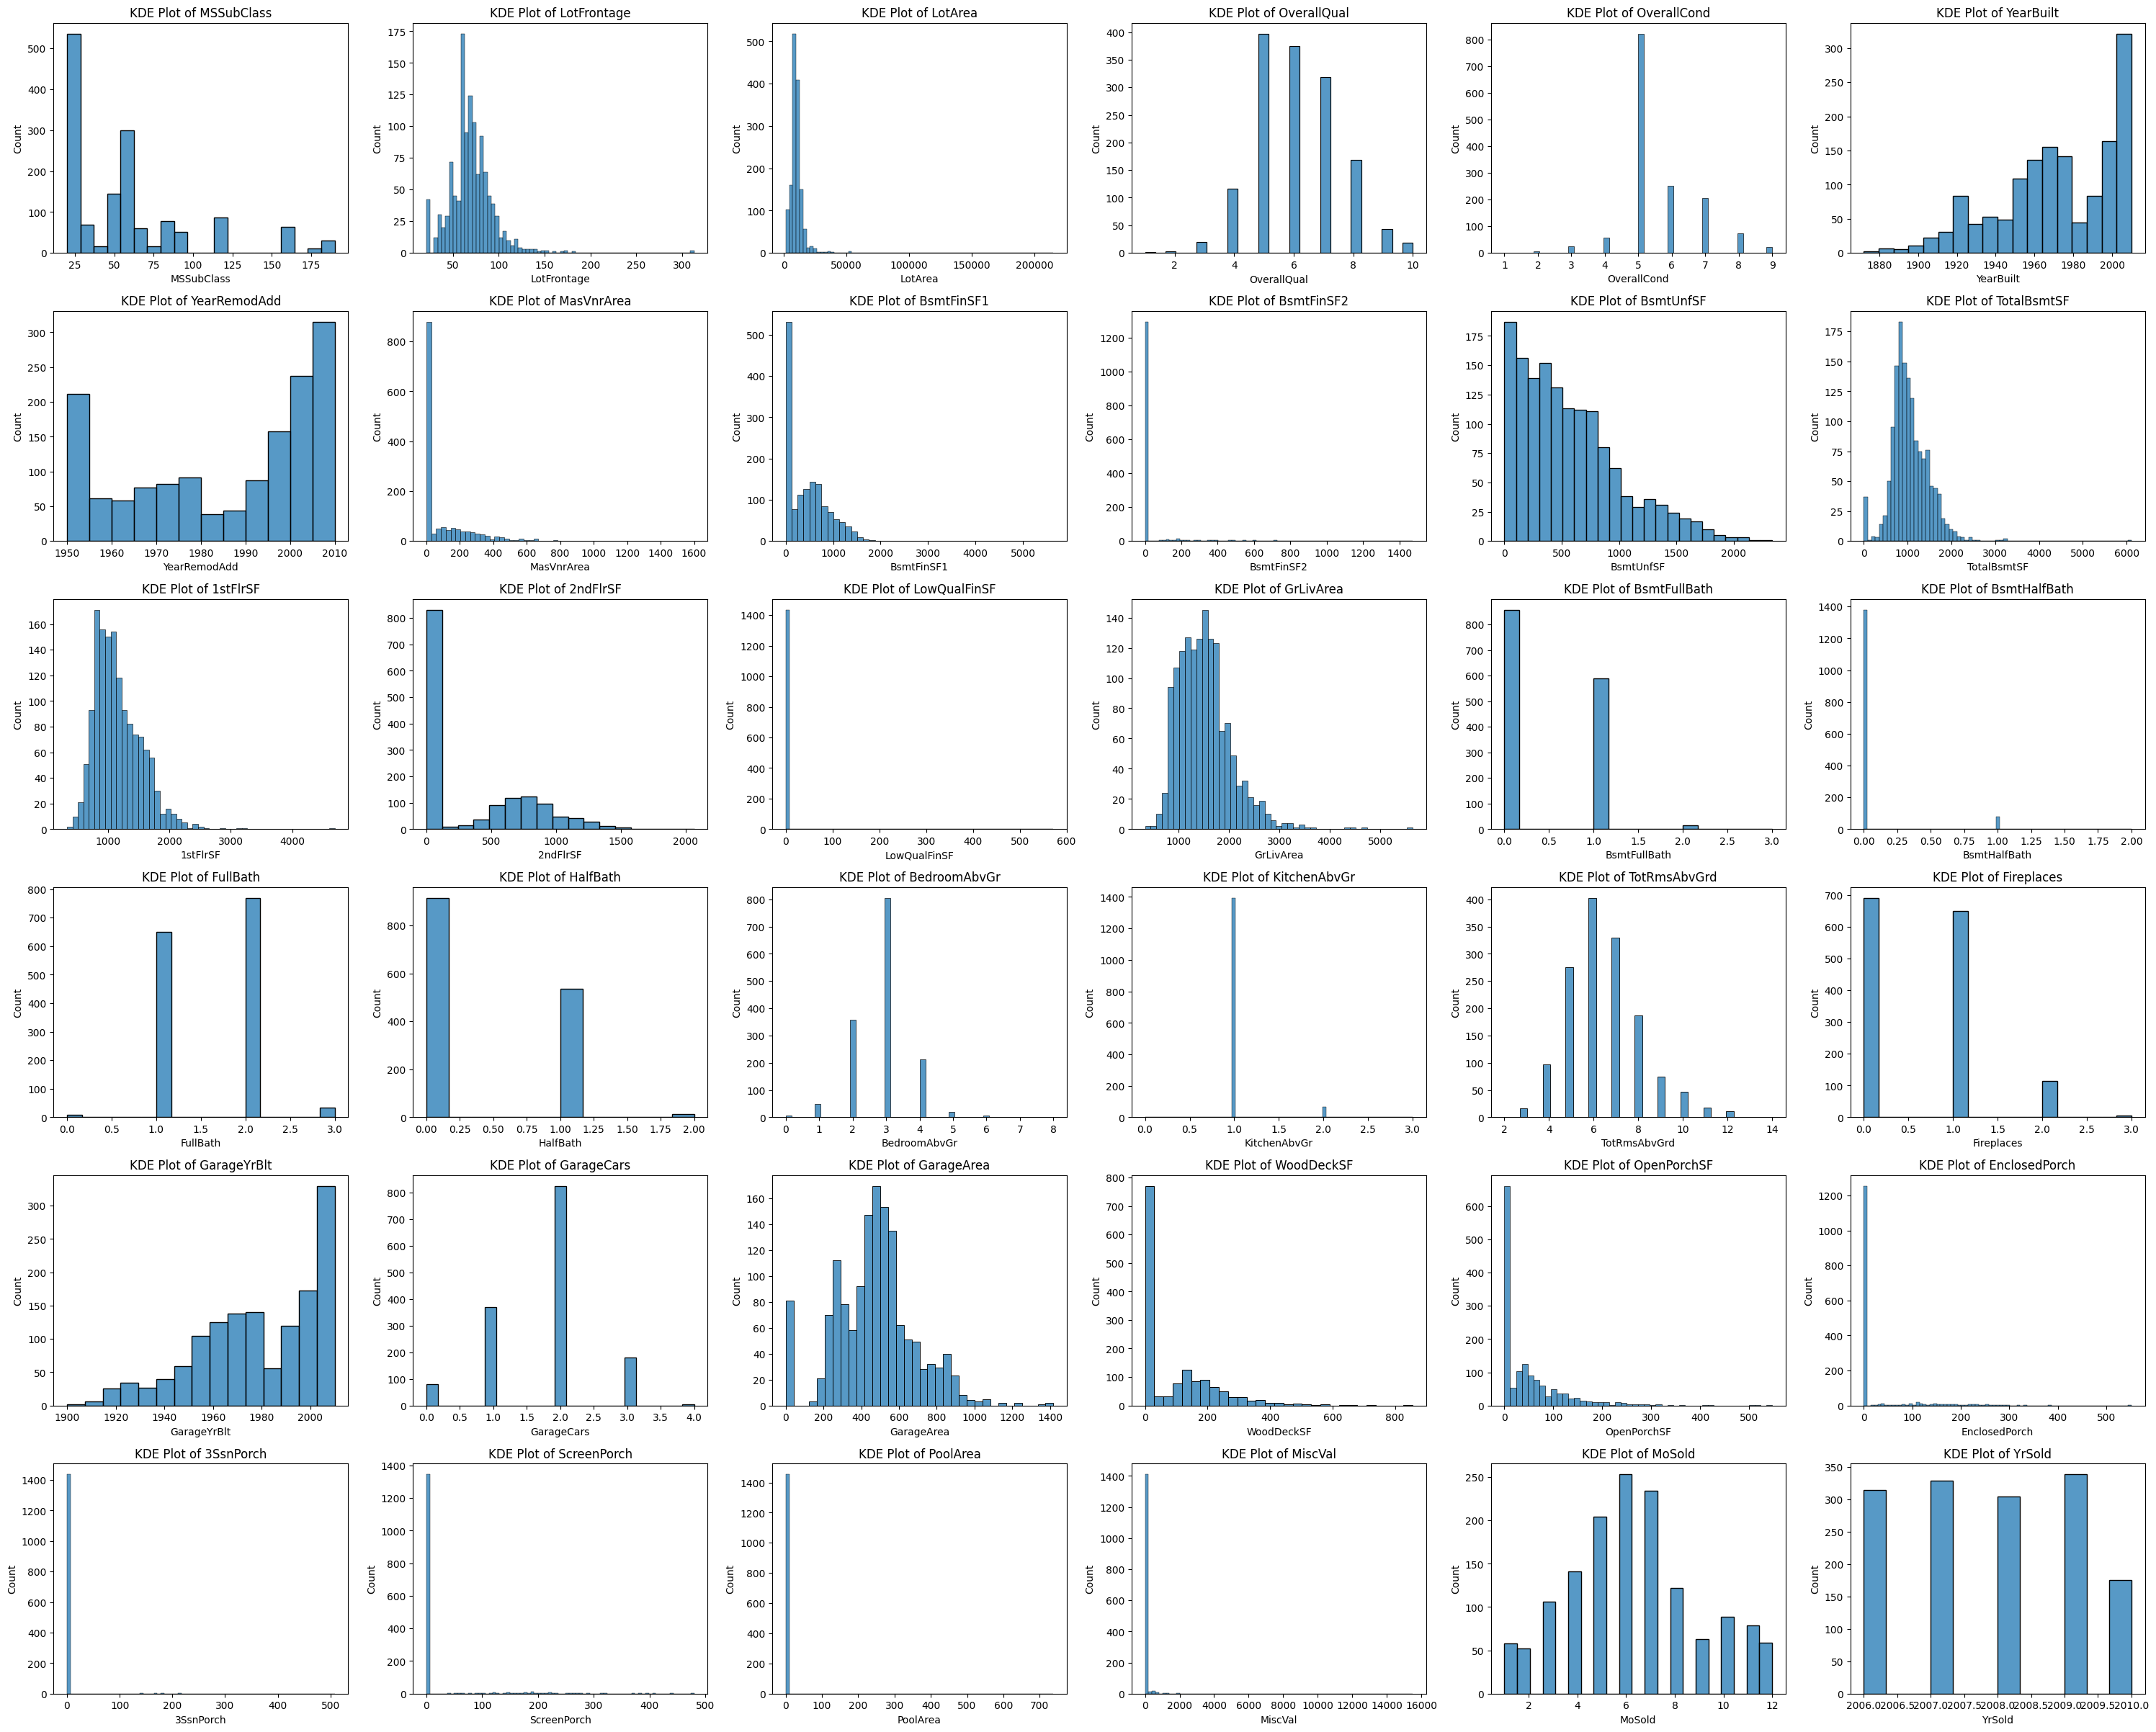

In [28]:
n_cols = 6
n_rows = int(np.ceil(len(num_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten() 

for i, col in enumerate(num_cols):
    sns.histplot(x_df_train[col], ax=axes[i], fill=True)
    axes[i].set_title(f'KDE Plot of {col}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## Categorical Features

# Data Preparation

## Numerical

In [ ]:
median_imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

cols_w_nulls = num_cols.columns[num_cols.isnull().any()].tolist()
# print(num_cols.dtypes[cols_w_nulls])
print(num_cols[cols_w_nulls].isnull().sum())
# results:
# LotFrontage    259
# MasVnrArea       8
# GarageYrBlt     81

# Missing values:
x_df_train['LotFrontage'] = median_imputer.fit_transform(x_df_train[['LotFrontage']]).ravel()
x_df_train['MasVnrArea'] = x_df_train['MasVnrArea'].fillna(0)
# for _, row in x_df_train.iterrows():
#     if pd.isna(row['GarageYrBlt']):
#         x_df_train['GarageYrBlt'] = x_df_train['YearBuilt']
x_df_train = x_df_train.drop(['GarageYrBlt'], axis=1)


LotFrontage    259
MasVnrArea       8
GarageYrBlt     81
dtype: int64
